In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
file_path = 'customer_reatil.csv.xlsx'
df = pd.read_excel(file_path)

In [ ]:
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())


First 5 Rows of Dataset:

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
label_encoder = LabelEncoder()

if 'Country' in df.columns:
    df['Country'] = label_encoder.fit_transform(df['Country'])

In [ ]:
average_quantity = df['Quantity'].mean()
df['Target'] = np.where(df['Quantity'] > average_quantity, 1, 0)

In [ ]:
X = df[['Quantity', 'UnitPrice', 'Country']]
y = df['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

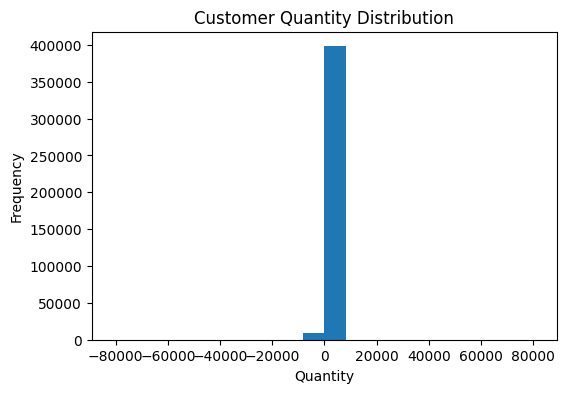

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Quantity'], bins=20)
plt.title('Customer Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()


In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)
log_cm = confusion_matrix(y_test, log_pred)

print("\n===== Logistic Regression =====")
print("Accuracy:", log_accuracy)
print("Confusion Matrix:\n", log_cm)


===== Logistic Regression =====
Accuracy: 0.9999877098542389
Confusion Matrix:
 [[68203     0]
 [    1 13162]]


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


dt_accuracy = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

print("\n===== Decision Tree Classifier =====")
print("Accuracy:", dt_accuracy)
print("Confusion Matrix:\n", dt_cm)


===== Decision Tree Classifier =====
Accuracy: 1.0
Confusion Matrix:
 [[68203     0]
 [    0 13163]]


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)

print("\n===== KNN Classifier =====")
print("Accuracy:", knn_accuracy)
print("Confusion Matrix:\n", knn_cm)


===== KNN Classifier =====
Accuracy: 0.9999508394169555
Confusion Matrix:
 [[68203     0]
 [    4 13159]]


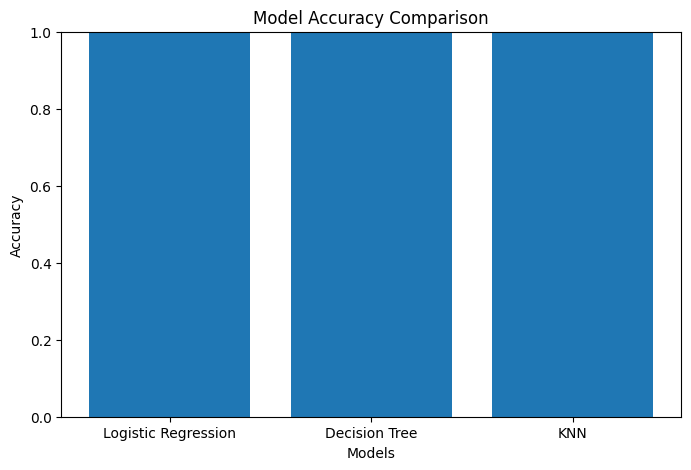

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [log_accuracy, dt_accuracy, knn_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [ ]:
print("\n===== Final Model Comparison =====")
print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("KNN Accuracy:", knn_accuracy)

best_accuracy = max(log_accuracy, dt_accuracy, knn_accuracy)

if best_accuracy == log_accuracy:
    print("\nBest Model: Logistic Regression")

elif best_accuracy == dt_accuracy:
    print("\nBest Model: Decision Tree")

else:
    print("\nBest Model: KNN")


===== Final Model Comparison =====
Logistic Regression Accuracy: 0.9999877098542389
Decision Tree Accuracy: 1.0
KNN Accuracy: 0.9999508394169555

Best Model: Decision Tree
